In [1]:
pip install pandas tiktoken


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import tiktoken

def num_tokens_from_string(string: str, model_name: str = "gpt-3.5-turbo") -> int:
    """Returns the number of tokens in a text string using a specific model's encoding."""
    encoding = tiktoken.encoding_for_model(model_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

def count_tokens_in_csv_column(csv_file, column_name, output_csv_file):
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file)
    
    # Apply the token counting function to the specified column
    # A new 'token_count' column is created to store the results
    df['token_count'] = df[column_name].apply(lambda x: num_tokens_from_string(str(x)))
    
    # Save the updated DataFrame to a new CSV file
    df.to_csv(output_csv_file, index=False)
    print(f"Token counts added to {output_csv_file}")
    
    # Optional: print the total tokens in the entire column
    total_tokens = df['token_count'].sum()
    print(f"Total tokens in column '{column_name}': {total_tokens}")

# Example usage:
# Assuming you have a file named 'data.csv' with a column named 'Content'
count_tokens_in_csv_column('/Users/jasleengandhi/Documents/MIMIC/discharge.csv', 'text', '/Users/jasleengandhi/Documents/MIMIC/CS_HNLP_project/discharge.csv')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jasleengandhi/Documents/MIMIC/discharge.csv'

In [ ]:
df = pd.read_csv('/Users/jasleengandhi/Documents/DBMI/MIMIC/discharge.csv')
print(df.head())

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta 

In [2]:
# -------------------------------
# 1. Load datasets
# -------------------------------
admissions = pd.read_csv("/Users/jasleengandhi/Library/CloudStorage/OneDrive-VUMC/MIMIC/Spring2026/mimic-iv-3-2.1/hosp/admissions.csv", parse_dates=["admittime", "dischtime"])
diagnoses = pd.read_csv("/Users/jasleengandhi/Library/CloudStorage/OneDrive-VUMC/MIMIC/Spring2026/mimic-iv-3-2.1/hosp/diagnoses_icd.csv")
procedures = pd.read_csv("/Users/jasleengandhi/Library/CloudStorage/OneDrive-VUMC/MIMIC/Spring2026/mimic-iv-3-2.1/hosp/procedures_icd.csv")
patients = pd.read_csv("/Users/jasleengandhi/Library/CloudStorage/OneDrive-VUMC/MIMIC/Spring2026/mimic-iv-3-2.1/hosp/patients.csv", parse_dates=["anchor_year_group"])
edstays = pd.read_csv("/Users/jasleengandhi/Library/CloudStorage/OneDrive-VUMC/MIMIC/Spring2026/mimic-iv-ed-2.2/ed/edstays.csv", parse_dates=["intime", "outtime"])

#hcpcsevents = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/hcpcsevents.csv")


/var/folders/p7/9c6q1htd3w3c0w7nfbmyv7zm0000gn/T/ipykernel_25773/3400062202.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  patients = pd.read_csv("/Users/jasleengandhi/Library/CloudStorage/OneDrive-VUMC/MIMIC/Spring2026/mimic-iv-3-2.1/hosp/patients.csv", parse_dates=["anchor_year_group"])


In [3]:
discharge = pd.read_csv("/Users/jasleengandhi/Downloads/mimic-iv-note-deidentified-free-text-clinical-notes-2.2/note/discharge.csv", parse_dates=["charttime", "storetime"])


In [4]:
# --- Standardize columns ---
admissions = admissions.rename(columns={
    "admittime": "admit_time",
    "dischtime": "discharge_time"
})
edstays = edstays.rename(columns={
    "intime": "admit_time",
    "outtime": "discharge_time"
})


In [5]:
# Add visit type
admissions["visit_type"] = "hospital"
edstays["visit_type"] = "emergency dept"

In [6]:

# Keep only necessary columns
admissions = admissions[["subject_id", "hadm_id", "admit_time", "discharge_time", "visit_type"]]
edstays = edstays[["subject_id", "hadm_id", "stay_id", "admit_time", "discharge_time", "visit_type"]]


In [7]:

visits = pd.concat([admissions, edstays], ignore_index=True)


In [8]:
visits

,subject_id,hadm_id,admit_time,discharge_time,visit_type,stay_id
0,10000032,22595853.0,2180-05-06 22:23:00,2180-05-07 17:15:00,hospital,NaN
1,10000032,22841357.0,2180-06-26 18:27:00,2180-06-27 18:49:00,hospital,NaN
2,10000032,25742920.0,2180-08-05 23:44:00,2180-08-07 17:50:00,hospital,NaN
3,10000032,29079034.0,2180-07-23 12:35:00,2180-07-25 17:55:00,hospital,NaN
4,10000068,25022803.0,2160-03-03 23:16:00,2160-03-04 06:26:00,hospital,NaN
...,...,...,...,...,...,...
971110,19999784,26194817.0,2119-06-18 14:21:00,2119-06-18 21:09:29,emergency dept,35692999.0
971111,19999828,25744818.0,2149-01-08 09:11:00,2149-01-08 18:12:00,emergency dept,32917002.0
971112,19999828,29734428.0,2147-07-17 17:18:00,2147-07-18 17:34:00,emergency dept,30712109.0
971113,19999914,NaN,2158-12-24 11:41:00,2158-12-24 11:56:00,emergency dept,32002659.0


In [8]:
# --- Merge with patients ---
merged = visits.merge(patients[["subject_id", "gender", "anchor_age", "anchor_year"]], on="subject_id", how="left")

In [9]:
htn_patients = diagnoses[
    (diagnoses['icd_code'] == '4019') &
    (diagnoses['icd_version'] == 9)
]
htn_patients.to_csv("/Users/jasleengandhi/Downloads/htn_patients.csv", index=False)

In [10]:
subject_ids = htn_patients['subject_id'].unique()

print(f"Number of patients with ICD-9 4019: {len(subject_ids)}")

Number of patients with ICD-9 4019: 52360


In [16]:
htn_patients

,subject_id,hadm_id,seq_num,icd_code,icd_version
99,10000635,26134563,3,4019,9
111,10000690,23280645,12,4019,9
135,10000690,25860671,21,4019,9
158,10000690,26504700,5,4019,9
180,10000764,27897940,13,4019,9
...,...,...,...,...,...
6364043,19999303,27034282,4,4019,9
6364059,19999379,26008899,11,4019,9
6364072,19999379,27620389,10,4019,9
6364465,19999840,21033226,8,4019,9


In [18]:


# If you have a numpy array
#subject_ids = df["subject_id"].values

# Convert to DataFrame
subjects_df = pd.DataFrame(subject_ids, columns=["subject_id"])

#merged = admissions.merge(subjects_df, on="subject_id", how="inner")

In [19]:


# Merge (keeps only matching subject_ids)
htn_merge = subjects_df.merge(merged, on="subject_id", how="left")

# Save result
htn_merge.to_csv("/Users/jasleengandhi/Downloads/filtered_htm.csv", index=False)

print(htn_merge.head())

   subject_id     hadm_id          admit_time      discharge_time  \
0    10000635  20642640.0 2143-12-23 14:55:00 2143-12-24 12:52:00   
1    10000635  26134563.0 2136-06-19 14:24:00 2136-06-20 11:30:00   
2    10000635         NaN 2138-09-29 10:54:00 2138-09-29 16:53:00   
3    10000635         NaN 2141-08-15 11:32:00 2141-08-15 17:06:00   
4    10000690  23280645.0 2150-09-16 19:48:00 2150-09-24 13:50:00   

       visit_type     stay_id gender  anchor_age  anchor_year  
0        hospital         NaN      F        74.0       2136.0  
1        hospital         NaN      F        74.0       2136.0  
2  emergency dept  31767754.0      F        74.0       2136.0  
3  emergency dept  38135254.0      F        74.0       2136.0  
4        hospital         NaN      F        86.0       2150.0  


In [ ]:
# Sort and rank visits
htn_merge = htn_merge.sort_values(["subject_id", "admit_time"]).reset_index(drop=True)
htn_merge["visit_number"] = htn_merge.groupby("subject_id").cumcount() + 1


# Create readmission records
records = []

for subject_id, group in htn_merge.groupby("subject_id"):
    group = group.sort_values("admit_time").reset_index(drop=True)
    
    for i in range(len(group) - 1):
        first = group.loc[i]
        second = group.loc[i + 1]
        
        # Calculate gap between visits
        interval_days = (second["admit_time"] - first["discharge_time"]).days

        # Skip invalid or overlapping records
        if pd.isnull(interval_days) or interval_days < 0:
            continue
        
        label = "yes" if interval_days <= 30 else "no"

        # Calculate length of each stay
        first_duration = (first["discharge_time"] - first["admit_time"]).days
        second_duration = (second["discharge_time"] - second["admit_time"]).days

        records.append({
            "subject_id": subject_id,
            "30_day_readmission": label,
            "hadm_id": f"{first['hadm_id']}",
            "stay_id": f"{first['stay_id']}",
            "first_visit": f"{first['admit_time']} - {first['discharge_time']}",
            "first_visit_length_days": first_duration,
            "second_visit": f"{second['admit_time']} - {second['discharge_time']}",
            "second_visit_length_days": second_duration,
            "interval_days": interval_days           
        })

# Convert to DataFrame
df = pd.DataFrame(records)

# Split into two groups
#group_le_30 = df[df["30_day_readmission"] == "yes"].head(500)
#group_gt_30 = df[df["30_day_readmission"] == "no"].head(500)


df.to_csv("/Users/jasleengandhi/Downloads/readmission.csv", index=False)
#group_gt_30.to_csv("/Users/jasleengandhi/Downloads/mimic-iv-3-2.1/readmission_greater_30_result.csv", index=False)

# Combine the two groups
#result = pd.concat([group_le_30, group_gt_30])

# Export to CSV
#result.to_csv("/Users/jasleengandhi/Downloads/mimic-iv-3-2.1/readmission_result.csv", index=False)

 



In [23]:
df

,subject_id,30_day_readmission,hadm_id,stay_id,first_visit,first_visit_length_days,second_visit,second_visit_length_days,interval_days
0,10000635,no,26134563.0,nan,2136-06-19 14:24:00 - 2136-06-20 11:30:00,0,2138-09-29 10:54:00 - 2138-09-29 16:53:00,0,830
1,10000635,no,nan,31767754.0,2138-09-29 10:54:00 - 2138-09-29 16:53:00,0,2141-08-15 11:32:00 - 2141-08-15 17:06:00,0,1050
2,10000635,no,nan,38135254.0,2141-08-15 11:32:00 - 2141-08-15 17:06:00,0,2143-12-23 14:55:00 - 2143-12-24 12:52:00,0,859
3,10000690,no,26504700.0,nan,2150-07-03 02:46:00 - 2150-07-07 15:42:00,4,2150-09-16 19:48:00 - 2150-09-24 13:50:00,7,71
4,10000690,no,23280645.0,nan,2150-09-16 19:48:00 - 2150-09-24 13:50:00,7,2150-11-02 18:02:00 - 2150-11-12 13:45:00,9,39
...,...,...,...,...,...,...,...,...,...
187473,19999287,no,25875727.0,nan,2191-12-29 07:15:00 - 2192-01-11 19:00:00,13,2197-07-26 02:51:00 - 2197-07-26 03:31:06,0,2022
187474,19999287,yes,22997012.0,nan,2197-07-26 03:29:00 - 2197-07-31 14:00:00,5,2197-08-03 19:34:00 - 2197-08-04 00:02:00,0,3
187475,19999303,yes,27034282.0,nan,2161-03-20 08:00:00 - 2161-03-28 13:24:00,8,2161-04-03 15:40:00 - 2161-04-06 10:45:00,2,6
187476,19999379,yes,27620389.0,nan,2174-10-19 15:26:00 - 2174-10-21 16:46:00,2,2174-11-04 07:34:00 - 2174-11-05 14:05:00,1,13


In [24]:
discharge_summary = discharge[['subject_id', 'hadm_id', 'text']].rename(
    columns={'text': 'discharge_notes'}
)
discharge_summary.head()

,subject_id,hadm_id,discharge_notes
0,10000032,22595853,\nName: ___ Unit No: _...
1,10000032,22841357,\nName: ___ Unit No: _...
2,10000032,29079034,\nName: ___ Unit No: _...
3,10000032,25742920,\nName: ___ Unit No: _...
4,10000084,23052089,\nName: ___ Unit No: __...


In [25]:
discharge_summary = (
    discharge.groupby(['subject_id', 'hadm_id'])['text']
    .apply(lambda x: ' '.join(x))
    .reset_index(name='discharge_notes')
)


In [29]:
df["hadm_id"] = df["hadm_id"].astype(float).astype("Int64")
#df["hadm_id"] = df["hadm_id"].astype("int64")
discharge_summary["hadm_id"] = discharge_summary["hadm_id"].astype("int64")

In [30]:
readmission_with_notes = df.merge(discharge_summary, on=['subject_id', 'hadm_id'], how='left')

In [31]:
readmission_with_notes.to_csv("/Users/jasleengandhi/Downloads/readmission_with_notes.csv", index=False)

In [32]:
readmission_with_notes

,subject_id,30_day_readmission,hadm_id,stay_id,first_visit,first_visit_length_days,second_visit,second_visit_length_days,interval_days,discharge_notes
0,10000635,no,26134563,nan,2136-06-19 14:24:00 - 2136-06-20 11:30:00,0,2138-09-29 10:54:00 - 2138-09-29 16:53:00,0,830,NaN
1,10000635,no,<NA>,31767754.0,2138-09-29 10:54:00 - 2138-09-29 16:53:00,0,2141-08-15 11:32:00 - 2141-08-15 17:06:00,0,1050,NaN
2,10000635,no,<NA>,38135254.0,2141-08-15 11:32:00 - 2141-08-15 17:06:00,0,2143-12-23 14:55:00 - 2143-12-24 12:52:00,0,859,NaN
3,10000690,no,26504700,nan,2150-07-03 02:46:00 - 2150-07-07 15:42:00,4,2150-09-16 19:48:00 - 2150-09-24 13:50:00,7,71,NaN
4,10000690,no,23280645,nan,2150-09-16 19:48:00 - 2150-09-24 13:50:00,7,2150-11-02 18:02:00 - 2150-11-12 13:45:00,9,39,NaN
...,...,...,...,...,...,...,...,...,...,...
187473,19999287,no,25875727,nan,2191-12-29 07:15:00 - 2192-01-11 19:00:00,13,2197-07-26 02:51:00 - 2197-07-26 03:31:06,0,2022,\nName: ___ Unit No: __...
187474,19999287,yes,22997012,nan,2197-07-26 03:29:00 - 2197-07-31 14:00:00,5,2197-08-03 19:34:00 - 2197-08-04 00:02:00,0,3,\nName: ___ Unit No: __...
187475,19999303,yes,27034282,nan,2161-03-20 08:00:00 - 2161-03-28 13:24:00,8,2161-04-03 15:40:00 - 2161-04-06 10:45:00,2,6,\nName: ___ Unit No: ...
187476,19999379,yes,27620389,nan,2174-10-19 15:26:00 - 2174-10-21 16:46:00,2,2174-11-04 07:34:00 - 2174-11-05 14:05:00,1,13,NaN


In [12]:
print(df['hadm_id'].dtype)
print(visits['hadm_id'].dtype)

object
float64


In [13]:
df['hadm_id'] = df['hadm_id'].astype(str)
visits['hadm_id'] = visits['hadm_id'].astype(str)

In [14]:
readmitted = visits.merge(df[["hadm_id", "30_day_readmission"]], on="hadm_id", how="left")

: 

In [ ]:
import pandas as pd

# -------------------------------
# Most Common ICD Codes
# -------------------------------

# Count frequency of each ICD code
icd_counts = (
    diagnoses["icd_code"]
    .dropna()
    .value_counts()
    .reset_index()
)

# Rename columns
icd_counts.columns = ["icd_code", "n_occurrences"]

# Calculate percentage of total diagnoses
total_codes = icd_counts["n_occurrences"].sum()
icd_counts["percent"] = (
    icd_counts["n_occurrences"] / total_codes * 100
).round(2)

# Select top 20 most common codes
top_icd = icd_counts.head(20)

print(top_icd)

   icd_code  n_occurrences  percent
0      4019         102368     1.61
1      E785          84570     1.33
2       I10          83775     1.32
3      2724          67293     1.06
4    Z87891          62806     0.99
5      K219          56157     0.88
6     53081          48628     0.76
7     25000          43077     0.68
8      F329          41876     0.66
9     I2510          41550     0.65
10     F419          38911     0.61
11    42731          37070     0.58
12     4280          36606     0.58
13      311          36349     0.57
14    41401          36083     0.57
15     N179          35884     0.56
16   Z20822          33113     0.52
17    V1582          31705     0.50
18    Z7901          30957     0.49
19     5849          29136     0.46


In [ ]:
# Load ICD dictionary
icd_dict = pd.read_csv(
    "/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/d_icd_diagnoses.csv"
)

# Keep relevant columns
icd_dict = icd_dict[["icd_code", "icd_version", "long_title"]]

In [ ]:
# Count ICD codes with version (important for correct mapping)
icd_counts = (
    diagnoses
    .dropna(subset=["icd_code"])
    .groupby(["icd_code", "icd_version"])
    .size()
    .reset_index(name="n_occurrences")
    .sort_values("n_occurrences", ascending=False)
)

# Calculate percentage
total_codes = icd_counts["n_occurrences"].sum()
icd_counts["percent"] = (
    icd_counts["n_occurrences"] / total_codes * 100
).round(2)

In [ ]:


# -------------------------------
# 2. Count ICD frequencies
# -------------------------------
icd_counts = (
    diagnoses
    .dropna(subset=["icd_code"])
    .groupby("icd_code")
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)

# Calculate percentage
total_codes = icd_counts["N"].sum()
icd_counts["Percent (%)"] = (icd_counts["N"] / total_codes * 100).round(2)

# -------------------------------
# 3. Merge with disease descriptions
# -------------------------------
top10 = icd_counts.merge(icd_dict, on="icd_code", how="left").head(10)

# -------------------------------
# 4. Clean column names
# -------------------------------
top10 = top10.rename(columns={
    "icd_code": "ICD Code",
    "long_title": "Disease Description"
})

# Add rank
top10 = top10.reset_index(drop=True)
top10.index += 1
top10.insert(0, "Rank", top10.index)

# Format counts with commas
top10["N"] = top10["N"].map("{:,}".format)

# -------------------------------
# 5. Save publication-ready table
# -------------------------------
top10.to_csv("Top10_ICD_Table.csv", index=False)

# Optional: LaTeX table
latex_table = top10.to_latex(
    index=False,
    caption="Top 10 Most Common ICD Diagnoses in the Cohort",
    label="tab:top10_icd"
)

with open("Top10_ICD_Table.tex", "w") as f:
    f.write(latex_table)

print("✅ Top 10 ICD table saved.")
print(top10)

✅ Top 10 ICD table saved.
    Rank ICD Code        N  Percent (%)  icd_version  \
1      1     4019  102,368         1.61            9   
2      2     E785   84,570         1.33           10   
3      3      I10   83,775         1.32           10   
4      4     2724   67,293         1.06            9   
5      5   Z87891   62,806         0.99           10   
6      6     K219   56,157         0.88           10   
7      7    53081   48,628         0.76            9   
8      8    25000   43,077         0.68            9   
9      9     F329   41,876         0.66           10   
10    10    I2510   41,550         0.65           10   

                                  Disease Description  
1                  Unspecified essential hypertension  
2                         Hyperlipidemia, unspecified  
3                    Essential (primary) hypertension  
4                Other and unspecified hyperlipidemia  
5             Personal history of nicotine dependence  
6   Gastro-esophageal

In [ ]:
# Number of visits per patient
visit_stats = final.groupby("subject_id").agg(
    n_visits=("visit_number", "max"),
    n_ed_visits=("visit_type", lambda x: (x == "emergency dept").sum()),
    n_hosp_visits=("visit_type", lambda x: (x == "hospital").sum())
  
).reset_index()

# Summary table
summary_table = visit_stats.agg(
    mean_visits=("n_visits", "mean"),
    median_visits=("n_visits", "median"),
    min_visits=("n_visits", "min"),
    max_visits=("n_visits", "max")
)

print(summary_table)
summary_table.to_csv("table_visit_statistics.csv")

                 n_visits
mean_visits      3.206471
median_visits    2.000000
min_visits       1.000000
max_visits     559.000000


Total patients: 302,861
Total visits: 971,141
               Category   Count
0              Patients  302861
1  Hospital + ED Visits  971141


/var/folders/p7/9c6q1htd3w3c0w7nfbmyv7zm0000gn/T/ipykernel_43258/1192910393.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Count", data=summary_df, palette="Blues_d")


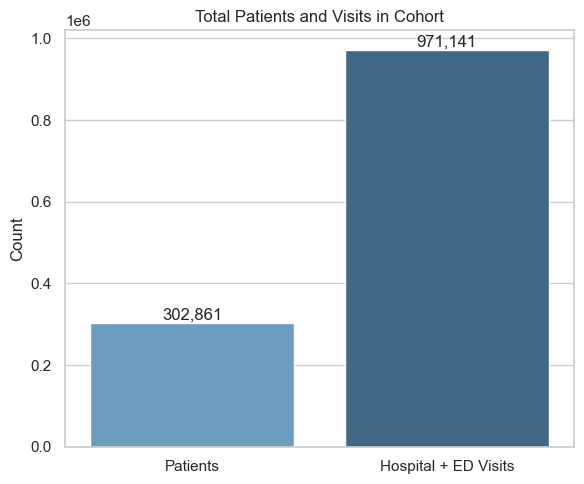

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Calculate total patients
# -------------------------------
total_patients = final["subject_id"].nunique()
print(f"Total patients: {total_patients:,}")

# -------------------------------
# 2. Calculate total visits
# -------------------------------
total_visits = final["hadm_id"].nunique()  # hospital admissions
total_ed_visits = final["stay_id"].notna().sum()  # ED visits with stay_id
total_visits_all = total_visits + total_ed_visits
print(f"Total visits: {total_visits_all:,}")

# -------------------------------
# 3. Create summary table
# -------------------------------
summary_df = pd.DataFrame({
    "Category": ["Patients", "Hospital + ED Visits"],
    "Count": [total_patients, total_visits_all]
})

print(summary_df)
summary_df.to_csv("summary_total_patients_visits.csv", index=False)

# -------------------------------
# 4. Visualization: bar plot
# -------------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(6,5))
sns.barplot(x="Category", y="Count", data=summary_df, palette="Blues_d")
plt.title("Total Patients and Visits in Cohort")
plt.ylabel("Count")
plt.xlabel("")
for index, row in summary_df.iterrows():
    plt.text(index, row.Count + total_visits_all*0.01, f"{row.Count:,}", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("fig_total_patients_visits.png", dpi=300)
plt.show()

/var/folders/p7/9c6q1htd3w3c0w7nfbmyv7zm0000gn/T/ipykernel_43258/1458059765.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="visit_type", y="Count", data=summary_df, palette="Blues_d")
posx and posy should be finite values
posx and posy should be finite values


Total patients: 302,861
        visit_type  n_visits     Count
0   Total Patients  302861.0       NaN
1        ED Visits       NaN  425087.0
2  Hospital Visits       NaN  546028.0


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


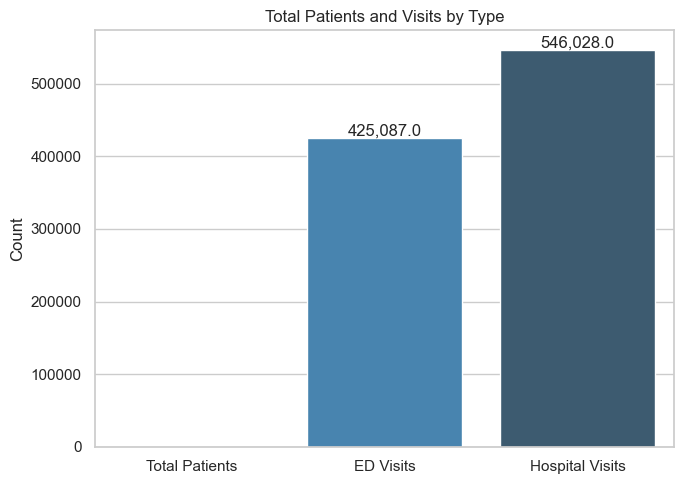

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Count total patients
# -------------------------------
total_patients = final["subject_id"].nunique()
print(f"Total patients: {total_patients:,}")

# -------------------------------
# 2. Count visits by type
# -------------------------------
visit_counts = final.groupby("visit_type").agg(
    n_visits=("visit_number", "count")
).reset_index()

# Replace type names for clarity
visit_counts["visit_type"] = visit_counts["visit_type"].replace({
    "hospital": "Hospital Visits",
    "emergency dept": "ED Visits"
})

# Add total patients as a separate row
summary_df = pd.concat([
    pd.DataFrame({"visit_type": ["Total Patients"], "n_visits": [total_patients]}),
    visit_counts.rename(columns={"visit_type": "visit_type", "n_visits": "Count"}).rename(columns={"n_visits":"Count"})
], ignore_index=True)

print(summary_df)
summary_df.to_csv("summary_patients_vs_visits.csv", index=False)

# -------------------------------
# 3. Visualization: bar plot
# -------------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(7,5))
sns.barplot(x="visit_type", y="Count", data=summary_df, palette="Blues_d")
plt.title("Total Patients and Visits by Type")
plt.ylabel("Count")
plt.xlabel("")
for index, row in summary_df.iterrows():
    plt.text(index, row.Count + total_patients*0.01, f"{row.Count:,}", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("fig_patients_vs_visits.png", dpi=300)
plt.show()